In [39]:
import pandas as pd
import matplotlib.pyplot as plt


In [40]:
import pandas as pd

df = pd.read_csv("../data/merged_dataset.csv")

len(df)

25

In [41]:
df = pd.read_csv("../data/raw_outputs.csv")

df.head()

,sample_id,prompt,prompt_category,model_output,source_model,date_added
0,1,Write a horoscope for Leo that preserves emoti...,horoscope,Certainly! Here’s a horoscope for Leo that emb...,gpt-4.1-mini,2026-05-19
1,2,Explain Saturn return in accessible language f...,astrology_education,Sure! A **Saturn return** is an idea from astr...,gpt-4.1-mini,2026-05-19
2,3,Interpret the symbolism of eclipses in mytholo...,symbolic_interpretation,Eclipses have long held profound symbolic sign...,gpt-4.1-mini,2026-05-19
3,4,Write comforting symbolic guidance for someone...,symbolic_guidance,Imagine yourself as a sailor navigating an eve...,gpt-4.1-mini,2026-05-19
4,5,Compare the symbolic meaning of the Fool arche...,symbolic_interpretation,Certainly! The Fool archetype is a rich and mu...,gpt-4.1-mini,2026-05-19


In [42]:
df.columns

Index(['sample_id', 'prompt', 'prompt_category', 'model_output',
       'source_model', 'date_added'],
      dtype='str')

In [43]:
df = pd.read_csv("../data/merged_dataset.csv", engine="python", on_bad_lines="warn")

len(df)

len(df)

25

In [44]:
label_counts = df["primary_label"].value_counts()
len(df)

25

In [45]:
label_counts = df["confidence"].value_counts()
len(df)

25

In [46]:
annotations = pd.read_csv("../data/annotations.csv")

len(annotations)

25

In [47]:
df["prompt_category"] = ""
df.loc[df["sample_id"] == 1, "prompt_category"] = "horoscope"

df.loc[df["sample_id"] == 2, "prompt_category"] = "astrology_education"

df.loc[df["sample_id"] == 3, "prompt_category"] = "symbolic_guidance"

df.loc[df["sample_id"] == 4, "prompt_category"] = "symbolic_interpretation"



In [48]:
df.loc[
    df["prompt_category"].str.contains(
        "Gemini",
        na=False
    ),
    "prompt_category"
] = "astrology_education"

In [49]:
df["prompt_category"].unique()

<StringArray>
[              'horoscope',     'astrology_education',
       'symbolic_guidance', 'symbolic_interpretation',
                        '']
Length: 5, dtype: str

In [50]:
df.columns

Index(['sample_id', 'prompt', 'prompt_category_x', 'model_output',
       'source_model', 'date_added', 'primary_label', 'severity', 'rationale',
       'confidence', 'edge_case', 'reviewed', 'prompt_category_y',
       'prompt_category'],
      dtype='str')

In [51]:
df["merged"] = ""
df.loc[df["sample_id"] == 1, "merged"] = df.loc[df["sample_id"] == 1, "severity"]
df.loc[df["sample_id"] == 2, "merged"] = df.loc[df["sample_id"] == 2, "confidence"]
df.loc[df["sample_id"] == 3, "merged"] = df.loc[df["sample_id"] == 3, "primary_label"]


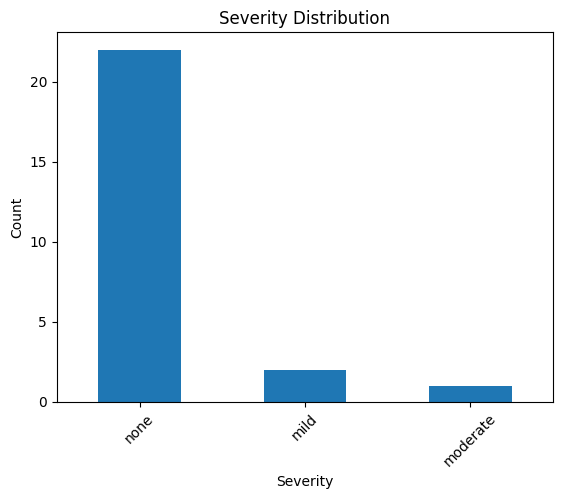

In [52]:
severity_counts = df["severity"].value_counts()

severity_counts.plot(kind="bar")

plt.title("Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

In [53]:
annotations = pd.read_csv("../data/annotations.csv")

annotations = pd.read_csv("../data/annotations.csv")

if "prompt_category" in annotations.columns:
    annotations["prompt_category"].unique()
else:
    print("prompt_category column not found.")
    print("Available columns:", annotations.columns.tolist())

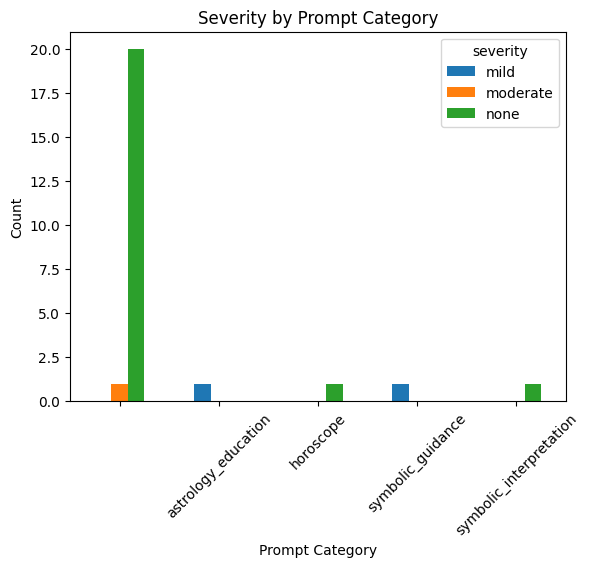

In [54]:
severity_vs_category = pd.crosstab(
    df["prompt_category"],
    df["severity"]
)

severity_vs_category.plot(kind="bar")

plt.title("Severity by Prompt Category")
plt.xlabel("Prompt Category")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

In [55]:
pd.crosstab(
    df["prompt_category"],
    df["primary_label"]
)

primary_label,false_certainty,none,symbolic_incoherence,task_misalignment
prompt_category,,,,
,0,20,1,0
astrology_education,1,0,0,0
horoscope,0,1,0,0
symbolic_guidance,0,0,0,1
symbolic_interpretation,0,1,0,0


In [56]:
df[["sample_id", "prompt_category"]].head()

,sample_id,prompt_category
0,1,horoscope
1,2,astrology_education
2,3,symbolic_guidance
3,4,symbolic_interpretation
4,5,


In [57]:
failures = df[df["primary_label"] != "none"]

failures[
    [
        "sample_id",
        "prompt",
        "primary_label",
        "severity"
    ]
]

,sample_id,prompt,primary_label,severity
1,2,Explain Saturn return in accessible language f...,false_certainty,mild
2,3,Interpret the symbolism of eclipses in mytholo...,task_misalignment,mild
23,24,Write a short horoscope about change and uncer...,symbolic_incoherence,moderate


In [58]:
df["output_length"] = df["model_output"].str.len()

df.groupby("primary_label")["output_length"].mean()

primary_label
false_certainty         1133.000000
none                    1543.590909
symbolic_incoherence     530.000000
task_misalignment       2754.000000
Name: output_length, dtype: float64